# Import bibliotek

In [2]:
import pyarrow
import pandas as pd
import sqlite3
import numpy
import geopandas
import geopy
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import xgboost
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import tabulate

# Pobranie danych

In [16]:
DB_FILE_PATH = "Dane\ceny_mieszkan.db"

In [17]:
con = sqlite3.connect(DB_FILE_PATH)

df = pd.read_sql_query("SELECT * FROM mieszkanka", con)
con.close()


In [18]:
df.describe()

,id,area,price,lat,lng,floor,floors,balcony,loggia,terrace,garden
count,99170.000000,99170.000000,9.917000e+04,99170.000000,99170.000000,95730.000000,99170.000000,35211.000000,6663.000000,9250.000000,10019.000000
mean,49585.500000,58.439314,7.961183e+05,18.304330,51.523458,2.683004,1.082414,7.979922,6.844572,25.032791,79.108702
std,28628.057435,31.481649,6.705208e+05,4.232786,2.891869,2.744205,0.322050,7.281906,5.928909,30.332002,101.381851
min,1.000000,5.000000,2.100000e+05,-5.273033,36.323581,-1.000000,1.000000,0.440000,0.670000,1.000000,0.970000
25%,24793.250000,40.230000,5.000000e+05,17.021745,50.810471,1.000000,1.000000,4.490000,3.620000,7.580000,24.625000
50%,49585.500000,51.390000,6.600000e+05,19.029263,52.080934,2.000000,1.000000,5.830000,5.270000,15.000000,46.120000
75%,74377.750000,66.670000,8.800000e+05,20.640453,52.456515,4.000000,1.000000,9.020000,8.000000,29.510000,93.010000
max,99170.000000,1239.300000,2.591640e+07,23.514184,54.830454,40.000000,5.000000,189.870000,86.480000,403.960000,1313.910000


## Odfiltrowanie samej polski i pozbycie się kolumny country

In [19]:
df = df[df["country"]=="PL"]
df = df.drop(columns="country")

## województwa

In [20]:
df.value_counts("voivodeship")

voivodeship
mazowieckie            18675
śląskie                10639
dolnośląskie           10437
pomorskie               9685
łódzkie                 9377
małopolskie             9341
wielkopolskie           8701
zachodniopomorskie      7215
kujawsko-pomorskie      3469
lubelskie               2778
warmińsko-mazurskie     1730
podlaskie               1387
podkarpackie            1261
świętokrzyskie          1077
opolskie                 140
lubuskie                 124
Name: count, dtype: int64

In [21]:
df.isnull().sum()

id                 0
developer          0
investment         0
number             0
area               0
price              0
voivodeship        0
county         68558
city            2803
district       37343
lat                0
lng                0
floor           3205
floors             0
balcony        60892
loggia         89392
terrace        89362
garden         86553
dtype: int64

Usuwamy na razie county i district, Na teraz ich nie potrzebujemy
Na potrzeby ćwiczenia usuwamy na city

In [22]:
df = df.drop(columns=["county","district"])
df = df[~df['city'].isna()]

In [23]:
df.isnull().sum()

id                 0
developer          0
investment         0
number             0
area               0
price              0
voivodeship        0
city               0
lat                0
lng                0
floor           2505
floors             0
balcony        58644
loggia         86609
terrace        86943
garden         84155
dtype: int64

In [29]:
df[['terrace','garden','loggia','balcony']] = df[['terrace','garden','loggia','balcony']].fillna(0)
df["floor"] = df["floor"].fillna(-1)

In [30]:
df.isnull().sum()

id             0
developer      0
investment     0
number         0
area           0
price          0
voivodeship    0
city           0
lat            0
lng            0
floor          0
floors         0
balcony        0
loggia         0
terrace        0
garden         0
dtype: int64

In [31]:
df["price_m2"] = df["price"]/df["area"]

Sprawdzamy czy to lokal usługowy

In [32]:
df["is_commercial"] = df["number"].str.startswith("U")

In [33]:
df.describe()

,id,area,price,lat,lng,floor,floors,balcony,loggia,terrace,garden,price_m2
count,93233.000000,93233.000000,9.323300e+04,93233.000000,93233.000000,93233.000000,93233.000000,93233.000000,93233.000000,93233.000000,93233.000000,93233.000000
mean,49577.007798,56.014762,7.429567e+05,18.985317,51.988230,2.628533,1.069428,2.939781,0.483560,1.160354,7.191349,13782.140294
std,28563.517981,26.734128,4.256041e+05,1.970037,1.388266,2.762055,0.299010,5.642625,2.326872,6.624174,35.644420,5255.657334
min,1.000000,5.000000,2.100000e+05,14.232837,49.281500,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,855.321552
25%,24734.000000,39.900000,5.000000e+05,17.064818,51.055766,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,10314.262691
50%,49498.000000,50.140000,6.500000e+05,19.091438,52.117108,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,12748.295286
75%,74375.000000,64.900000,8.500000e+05,20.673060,52.569699,4.000000,1.000000,4.700000,0.000000,0.000000,0.000000,15912.305516
max,99170.000000,1239.300000,2.065860e+07,23.514184,54.830454,35.000000,5.000000,138.620000,86.480000,403.960000,1313.910000,198000.000000


Poprawki w podejrzanych pozycjach - błędy w danych

In [34]:
df.loc[df["id"] == 25177, "area"] /= 10
df.loc[df["id"] == 29745, "area"] = 72.27

df["price_m2"] = df["price"] / df["area"]

## Rozkład danych ceny metra kwadratowego
Z podziałem na mieszkalne i usługowe

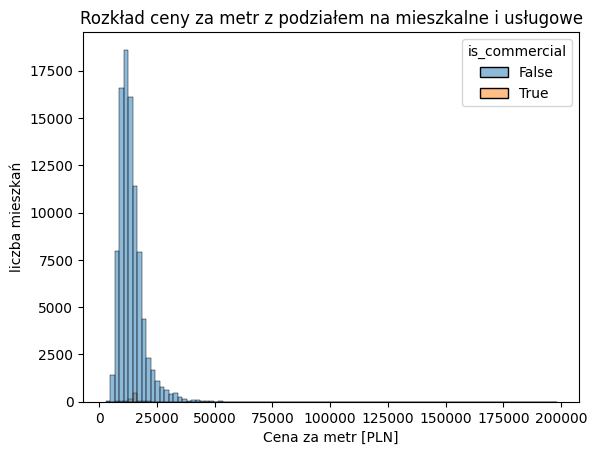

In [38]:
g = sns.histplot(
    x=df["price_m2"],
    bins=100,
    hue=df["is_commercial"])
plt.xlabel("Cena za metr [PLN]")
plt.ylabel("liczba mieszkań")
plt.title("Rozkład ceny za metr z podziałem na mieszkalne i usługowe")

plt.show(g)

Obliczamy ile jest mieszkań powyżej 30k, shape daje nam ilość wierszy

In [46]:
print(100 * df[df["price_m2"] > 30000].shape[0]/df.shape[0])
print(100 * df[df["price_m2"] < 5000].shape[0]/df.shape[0])

1.8148080615232804
0.07722587495843747


Obcinamy te z poza zakresu 5k-30k

In [49]:
df = df[df["price_m2"].between(5000, 30000)].copy()

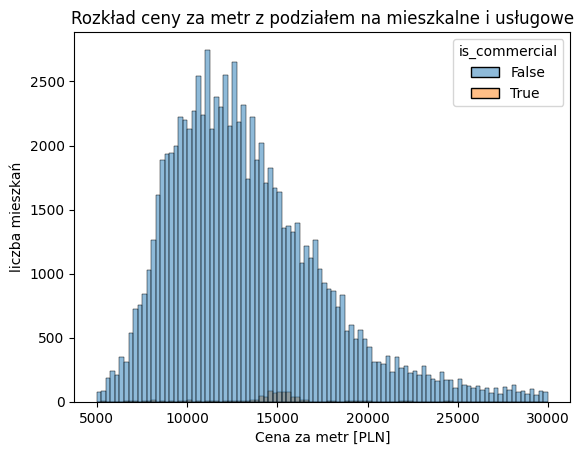

In [50]:
g = sns.histplot(
    x=df["price_m2"],
    bins=100,
    hue=df["is_commercial"])
plt.xlabel("Cena za metr [PLN]")
plt.ylabel("liczba mieszkań")
plt.title("Rozkład ceny za metr z podziałem na mieszkalne i usługowe")

plt.show(g)

Rozkład powierzchni - wolnostojące kontra piętrowe 

In [51]:
df["is_detached"] = df["floor"] ==-1

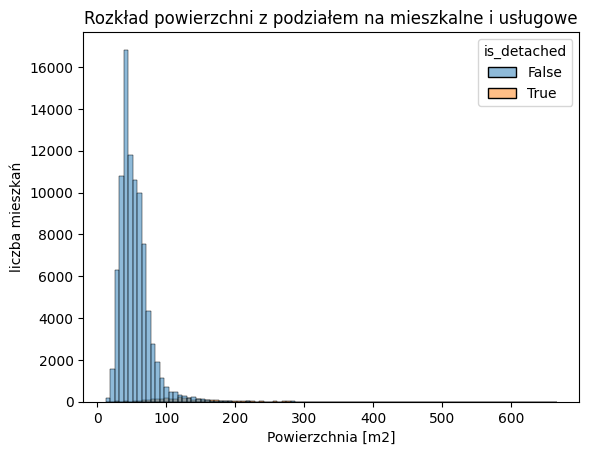

In [53]:
g = sns.histplot(
    x=df["area"],
    bins=100,
    hue=df["is_detached"])
plt.xlabel("Powierzchnia [m2]")
plt.ylabel("liczba mieszkań")
plt.title("Rozkład powierzchni z podziałem na mieszkalne i usługowe")

plt.show(g)

In [57]:
print(100*df[df["area"]>200].shape[0]/df.shape[0])

0.38264329991581847


Utniemy do 200 ale tylko na wykresie

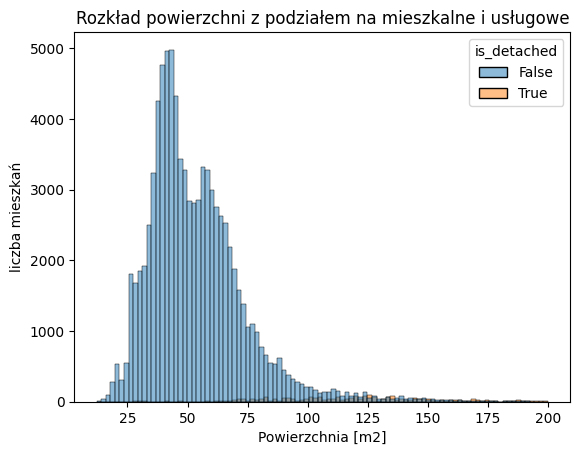

In [59]:
g = sns.histplot(
    data=df[df["area"]<=200],
    x = "area",
    bins=100,
    hue=df["is_detached"])
plt.xlabel("Powierzchnia [m2]")
plt.ylabel("liczba mieszkań")
plt.title("Rozkład powierzchni z podziałem na mieszkalne i usługowe")

plt.show(g)

## Zobaczmy gdzie są te mieszkania

lat - szerokosc (N/S)
lng - długość (E/W)

Są zamienione długość z szerokością

In [62]:
df = df.rename(columns={"lng":"lat","lat":"lng"})

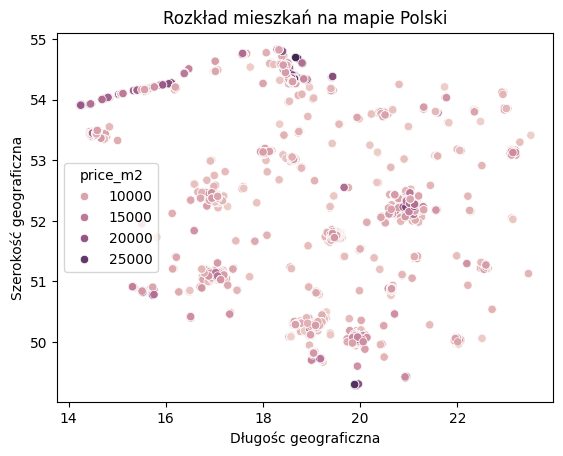

In [64]:
g = sns.scatterplot( data=df,
    x="lng",
    y="lat",
    hue="price_m2"
)

plt.xlabel("Długośc geograficzna")
plt.ylabel("Szerokość geograficzna")
plt.title("Rozkład mieszkań na mapie Polski")

plt.show(g)

In [65]:
df.to_parquet("ceny_mieszkan_v1.parquet", index=False)

## Zadania dodatkowe
- wylicz średnią (albo medianę) cenę metra kwadratowego dla konkretnego dewelopera i konkretnej inwestycji - należy spodziewać się, że powinny to być w miare zbliżone wartości
- możesz wyliczyć też odchylenie standardowe
- poszukaj takich rekordów, które są odstające - czyli ich cena za metr kwadratowy jest poniżej wartości średnia minus odchylenie standardowe oraz powyżej średnia plus odchylenie standardowe
- zastanów się co z tym zrobić - podmienić wartości? na jakie? wyrzucić te rekordy?
- spróbuj też narysować wykres ceny (price) od powierzchni (area) - zapewne pojawią się jakieś pojedyncze odstające punkty - co to za rekordy? co z nimi zrobić?

In [4]:
df2 = df[["price_m2","developer"]].groupby(by=["developer"]).mean().sort_values("price_m2")
df3 = df[["price_m2","investment"]].groupby(by=["investment"]).std().sort_values("price_m2")

In [5]:
df[["price_m2","developer"]].groupby(by=["developer"]).agg(['mean','median','std']).sort_values(by=('price_m2', 'mean'))

price_m2                           
                                             mean        median          std
developer                                                                   
Fenix Construction Sp. z o.o. Sp.k.   5040.637699   5040.637699    55.259986
Shell House Sp. z o.o.                5157.630069   5157.630069     0.000000
Sato                                  5356.125356   5356.125356          NaN
Góralczyk Nieruchomości               5361.090641   5342.667649    77.068904
Mega Chaty                            5387.552748   5399.366971   144.102748
...                                           ...           ...          ...
Ciril                                28424.529681  28424.529681  1973.936401
MJM 11 Sp. z o.o.                    28727.770178  28727.770178          NaN
Olivia Home Sp. z o.o.               28802.483426  29454.826921  1349.540050
Lions Estate                         29254.642585  29254.642585   899.398094
Monea Properties                     29623.093407  29623.093407          NaN

[1112 rows x 3 columns]

Zachowanie rozmiaru (Broadcasting)
agg (agregacja): Zmniejsza liczbę wierszy. Jeśli masz 100 mieszkań u 5 deweloperów, agg zwróci tylko 5 wierszy.

transform: Wylicza średnią dla dewelopera, ale "rozsmarowuje" ją (powiela) na wszystkie 100 wierszy. Dzięki temu możesz dodać wynik jako nową kolumnę bezpośrednio do oryginalnego df.

In [6]:
df['mean_dev'] = df.groupby('developer')['price_m2'].transform('mean')
df['std_dev'] = df.groupby('developer')['price_m2'].transform('std')

df["min_price"] = df["mean_dev"] - df["std_dev"]
df["max_price"] = df["mean_dev"] + df["std_dev"]

In [7]:
df2 = df[(df["price_m2"]>df["max_price"])|
         (df["price_m2"]<df["min_price"])]

In [8]:
df['mean_inv'] = df.groupby('investment')['price_m2'].transform('mean')
df['std_inv'] = df.groupby('investment')['price_m2'].transform('std')

df["min_price_inv"] = df["mean_inv"] - df["std_inv"]
df["max_price_inv"] = df["mean_inv"] + df["std_inv"]

In [9]:
df3 = df[(df["price_m2"]>df["max_price_inv"])|
         (df["price_m2"]<df["min_price_inv"])]

In [3]:
df = pd.read_parquet("ceny_mieszkan_v1.parquet")

### Wykres ceny od powierzchni

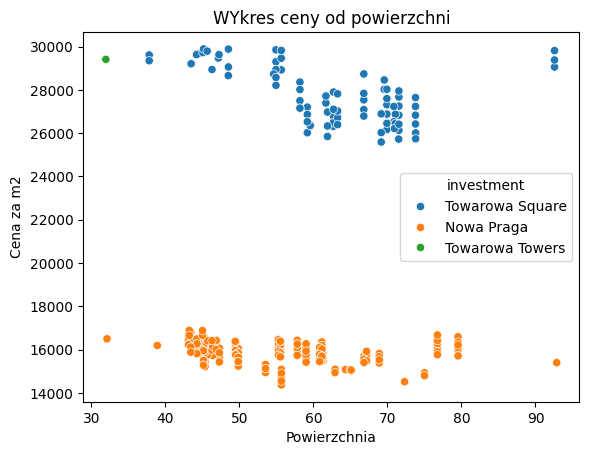

In [14]:
g = sns.scatterplot( data=df[df["developer"]=="ASBUD Group"],
    x="area",
    y="price_m2",
    hue="investment"
)

plt.xlabel("Powierzchnia")
plt.ylabel("Cena za m2")
plt.title("WYkres ceny od powierzchni")

plt.show(g)